In [1]:
!pip install torch torchvision scikit-learn matplotlib seaborn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

In [4]:
dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))

100%|██████████| 170M/170M [00:03<00:00, 43.3MB/s]


Training Images: 40000
Validation Images: 10000


In [5]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN,self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )

    def forward(self,x):

        x = self.conv(x)
        x = x.view(x.size(0),-1)
        x = self.fc(x)

        return x

model = CNN()
print(model)

CNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [7]:
train_losses = []

epochs = 10

for epoch in range(epochs):

    running_loss = 0

    model.train()

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}"
    )

Epoch [1/10] Loss: 1.5898
Epoch [2/10] Loss: 1.2474
Epoch [3/10] Loss: 1.0789
Epoch [4/10] Loss: 0.9727
Epoch [5/10] Loss: 0.8982
Epoch [6/10] Loss: 0.8449
Epoch [7/10] Loss: 0.8015
Epoch [8/10] Loss: 0.7628
Epoch [9/10] Loss: 0.7449
Epoch [10/10] Loss: 0.7142


In [8]:
correct = 0
total = 0

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

accuracy = 100 * correct / total

print("Accuracy:", accuracy)

Accuracy: 74.18


In [9]:
print(
    classification_report(
        all_labels,
        all_preds
    )
)

              precision    recall  f1-score   support

           0       0.68      0.86      0.76      1027
           1       0.81      0.91      0.85       976
           2       0.64      0.63      0.64       976
           3       0.59      0.57      0.58       981
           4       0.69      0.71      0.70      1037
           5       0.83      0.49      0.62      1015
           6       0.79      0.81      0.80      1006
           7       0.79      0.78      0.79      1006
           8       0.82      0.86      0.84       969
           9       0.82      0.79      0.81      1007

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



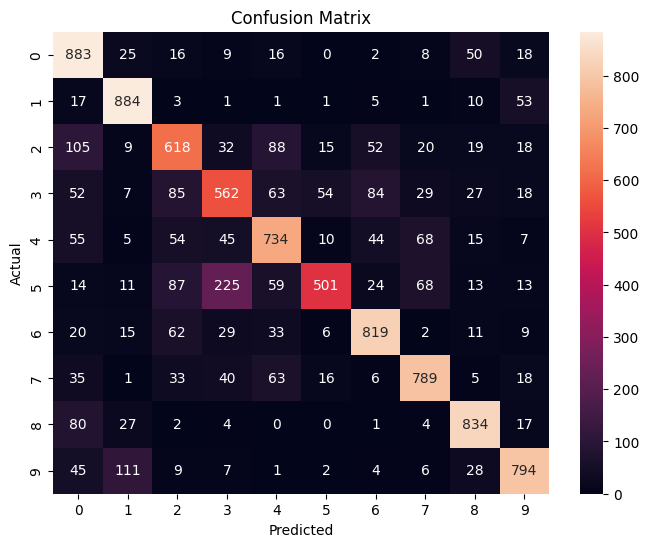

In [10]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

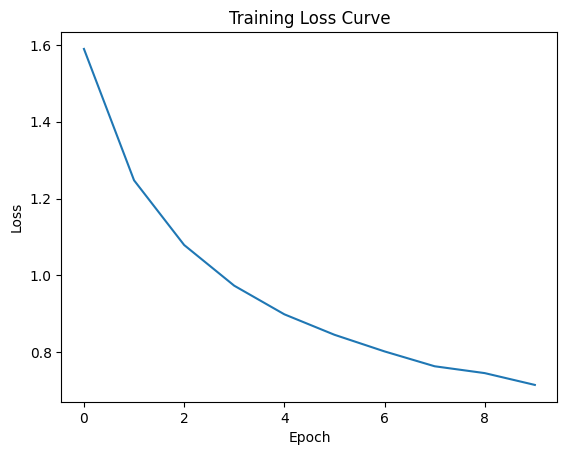

In [11]:
plt.plot(train_losses)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()